In [ ]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & VISUAL CONFIGURATION
# ==============================================================================
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Plot aesthetic configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print("Statistical toolkit loaded successfully!")

NumPy Version: 2.1.3
Pandas Version: 2.2.3
Statistical toolkit loaded successfully!


In [ ]:
# ==============================================================================
# SECTION 1: POPULATION VS SAMPLE & BESSEL'S CORRECTION
# ==============================================================================
# Concept Summary:
# - POPULATION: The entire group of interest (Size: N). Parameters: μ (mean), σ² (variance).
# - SAMPLE: A representative subset drawn from the population (Size: n). Statistics: x̄ (mean), s² (variance).
#
# Bessel's Correction (Why divide sample variance by n - 1?):
# Using sample mean x̄ instead of true population mean μ systematically underestimates
# spread because sample data points are closer to x̄ than to μ.
# Dividing by (n - 1) removes this bias, making s² an UNBIASED estimator of σ².

np.random.seed(42)
true_population = np.random.normal(loc=100.0, scale=15.0, size=1_000_000)

# Extract a small sample
sample_n = 30
sample_data = np.random.choice(true_population, size=sample_n, replace=False)
# mean = avg of all the numbers
print(f"Population Mean (μ):    {np.mean(true_population):.4f}  | Parameter")  #.4f = till 4 decimal places
print(f"Sample Mean (x̄):        {np.mean(sample_data):.4f}  | Statistic (Estimator)")
print(f"\nBiased Sample Std (N):  {np.std(sample_data, ddof=0):.4f}  (Underestimates true σ)")
print(f"Unbiased Sample Std(N-1): {np.std(sample_data, ddof=1):.4f}  (Bessel corrected -> matches σ={15.0})")

Population Mean (μ):    99.9760  | Parameter
Sample Mean (x̄):        96.6830  | Statistic (Estimator)

Biased Sample Std (N):  17.7833  (Underestimates true σ)
Unbiased Sample Std(N-1): 18.0873  (Bessel corrected -> matches σ=15.0)


two types of discriptive : major of central and major of dispersion

In [ ]:
# ==============================================================================
# SECTION 2: CENTRAL TENDENCY & WORKED SALARY EXAMPLE
# ==============================================================================
# Measures:
# - MEAN (Arithmetic Average): Sensitive to all values; pulled heavily by extreme outliers.
# - MEDIAN (50th Percentile): Positional midpoint; robust to skewness and outliers.
# - MODE: Most frequently occurring value; best for discrete/categorical data.

# WORKED EXAMPLE: 9 software engineers and 1 executive
salaries = np.array([55_000, 58_000, 60_000, 62_000, 65_000, 68_000, 70_000, 72_000, 75_000, 1_500_000])

mean_sal = np.mean(salaries)
median_sal = np.median(salaries)
mode_sal = stats.mode(salaries, keepdims=True).mode[0]  # mode funcis not abvail in np lib.. its in stats in  scipy

print("=== Tech Startup Salary Distribution ===")
print(f"Individual Salaries: {salaries}")
print(f"Mean Salary:   ${mean_sal:,.2f}  <-- Heavily distorted by the $1.5M executive")
print(f"Median Salary: ${median_sal:,.2f}  <-- Represents the typical employee experience")
print(f"Mode Salary:   ${mode_sal:,.2f}")
print("\nAnalytical Takeaway: When data is skewed or has outliers, report the MEDIAN.")

=== Tech Startup Salary Distribution ===
Individual Salaries: [  55000   58000   60000   62000   65000   68000   70000   72000   75000
 1500000]
Mean Salary:   $208,500.00  <-- Heavily distorted by the $1.5M executive
Median Salary: $66,500.00  <-- Represents the typical employee experience
Mode Salary:   $55,000.00

Analytical Takeaway: When data is skewed or has outliers, report the MEDIAN.


In [ ]:
# ==============================================================================
# SECTION 3: MEASURES OF DISPERSION & WHY WE SQUARE DEVIATIONS
# ==============================================================================
# 1. Range: Max - Min (crude, highly sensitive to extremes)
# 2. Variance (s²): Average squared deviation from the mean
# 3. Standard Deviation (s): Square root of variance; returned to original feature units
# 4. Coefficient of Variation (CV): (s / μ) * 100% -> Unitless relative dispersion

# WHY SQUARE DEVIATIONS INSTEAD OF SUMMING RAW DIFFERENCES?
# A. The Zero-Sum Cancellation: Σ(x - μ) is ALWAYS identically 0 because negative and
#    positive errors cancel out.
# B. Non-Linear Penalty: Squaring penalises large errors progressively more than small ones.
# C. Differentiability: Absolute values |x - μ| have a sharp cusp at zero (non-differentiable),
#    making squared math smoother for calculus and gradient optimization.

data_disp = np.array([10, 12, 14, 16, 18, 20])
diffs = data_disp - np.mean(data_disp)

print(f"Values: {data_disp}")
print(f"Deviations from mean ({np.mean(data_disp)}): {diffs}")
print(f"Sum of raw deviations: {np.sum(diffs):.2f} (Cancels to 0!)")
print(f"Sum of squared deviations: {np.sum(diffs**2):.2f}")
print(f"Sample Std Dev (s): {np.std(data_disp, ddof=1):.2f}")
print(f"Coefficient of Variation (CV): {(np.std(data_disp, ddof=1) / np.mean(data_disp)) * 100:.2f}%")

Values: [10 12 14 16 18 20]
Deviations from mean (15.0): [-5. -3. -1.  1.  3.  5.]
Sum of raw deviations: 0.00 (Cancels to 0!)
Sum of squared deviations: 70.00
Sample Std Dev (s): 3.74
Coefficient of Variation (CV): 24.94%


--- Five-Number Summary & Fences ---
Min: 2 | Q1: 6.25 | Median: 8.5 | Q3: 11.75 | Max: 28
IQR: 5.50 | Lower Fence: -2.00 | Upper Fence: 20.00
Whiskers: [2, 15]


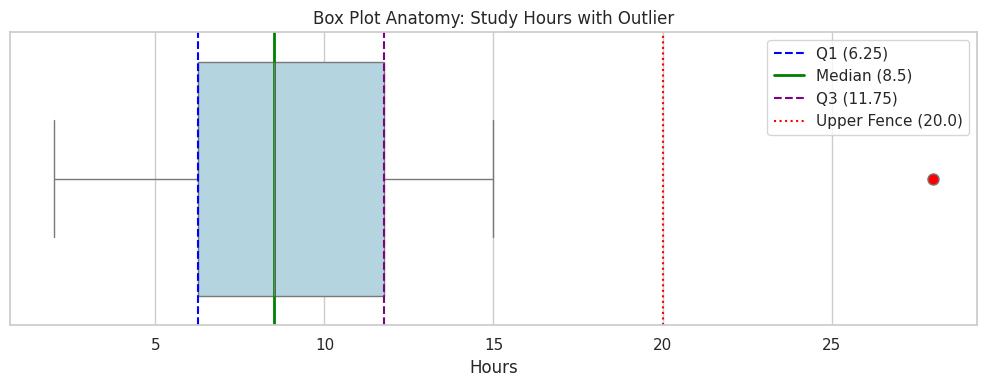

In [ ]:
# ==============================================================================
# SECTION 4: POSITION METRICS, FIVE-NUMBER SUMMARY & BOX PLOT ANATOMY
# ==============================================================================
# The Five-Number Summary: [Min, Q1 (25%), Q2/Median (50%), Q3 (75%), Max]
# Interquartile Range (IQR) = Q3 - Q1 (Middle 50% of data)

study_hours = np.array([2, 4, 5, 6, 7, 8, 8, 9, 10, 11, 12, 14, 15, 28]) # 28 is an outlier

q1 = np.percentile(study_hours, 25)
median_q2 = np.percentile(study_hours, 50)
q3 = np.percentile(study_hours, 75)
iqr = q3 - q1

# Tukey Fences
lower_fence = q1 - 1.5 * iqr    #lowest and highest non outliner data pgts - whisker low and whisker high
upper_fence = q3 + 1.5 * iqr     #tukey juss finds the outliners and whiskers find exactly which is the highest outlienerer nad lower outliner

# Whiskers extend to the lowest and highest non-outlier data points within fences
whisker_low = study_hours[study_hours >= lower_fence].min()
whisker_high = study_hours[study_hours <= upper_fence].max()

print("--- Five-Number Summary & Fences ---")
print(f"Min: {study_hours.min()} | Q1: {q1} | Median: {median_q2} | Q3: {q3} | Max: {study_hours.max()}")
print(f"IQR: {iqr:.2f} | Lower Fence: {lower_fence:.2f} | Upper Fence: {upper_fence:.2f}")
print(f"Whiskers: [{whisker_low}, {whisker_high}]")

#lib for visualization - matplotlib


# Visual Box Plot Anatomy
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=study_hours, color="lightblue", flierprops={"marker": "o", "markersize": 8, "markerfacecolor": "red"})
ax.axvline(q1, color='blue', linestyle='--', label=f'Q1 ({q1})')
ax.axvline(median_q2, color='green', linestyle='-', linewidth=2, label=f'Median ({median_q2})')
ax.axvline(q3, color='purple', linestyle='--', label=f'Q3 ({q3})')
ax.axvline(upper_fence, color='red', linestyle=':', label=f'Upper Fence ({upper_fence})')
ax.set_title("Box Plot Anatomy: Study Hours with Outlier")
ax.set_xlabel("Hours")
ax.legend()
plt.tight_layout()
plt.show()

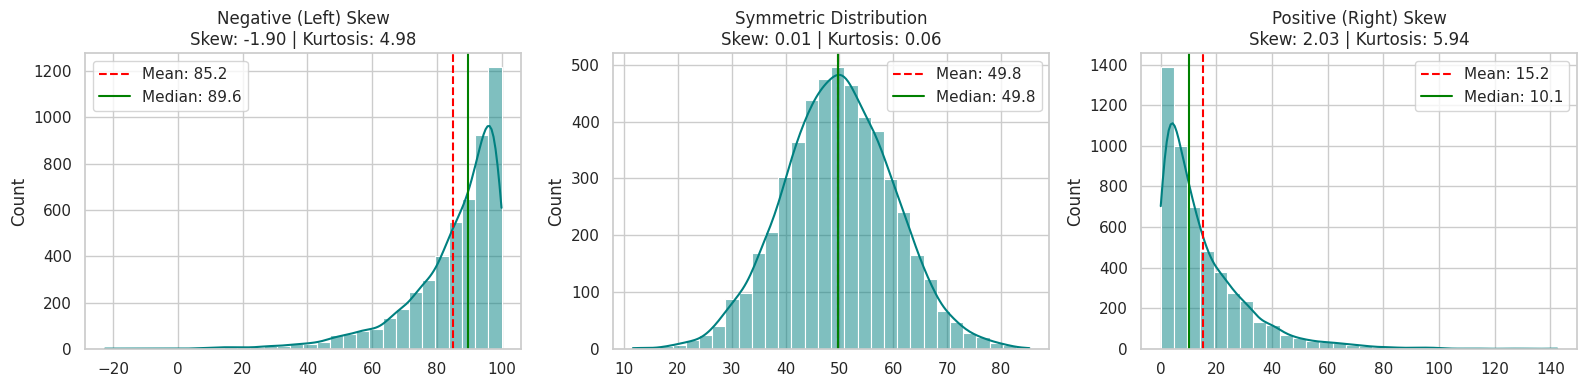

In [ ]:
# ==============================================================================
# SECTION 5: SHAPE METRICS — SKEWNESS & KURTOSIS
# ==============================================================================
# SKEWNESS (Asymmetry of the distribution):
# - Negative (Left) Skew:  Tail stretches left.  Mean < Median < Mode (Skew < -0.5)
# - Symmetric:            Tail balance equal.   Mean ≈ Median ≈ Mode (Skew ≈ 0)
# - Positive (Right) Skew: Tail stretches right. Mean > Median > Mode (Skew > +0.5)
#
# KURTOSIS (Tail weight / Outlier propensity relative to normal distribution):
# - Mesokurtic (Excess Kurtosis ≈ 0): Normal bell curve tails.
# - Leptokurtic (Excess Kurtosis > 0): Heavy tails, sharp peak, prone to extreme outliers.
# - Platykurtic (Excess Kurtosis < 0): Light tails, flat peak, low outlier frequency.

np.random.seed(42)
left_skew = 100 - np.random.exponential(scale=15, size=5000)   # Left/Negatively skewed
sym_dist  = np.random.normal(loc=50, scale=10, size=5000)        # Symmetric
right_skew = np.random.exponential(scale=15, size=5000)          # Right/Positively skewed

fig, axes = plt.subplots(1, 3, figsize=(16, 4))  #sns- seaborn           : extended verison of matplot lib??? why . diff??

for ax, data, name in zip(axes, [left_skew, sym_dist, right_skew],
                          ["Negative (Left) Skew", "Symmetric Distribution", "Positive (Right) Skew"]):
    sns.histplot(data, kde=True, ax=ax, color='teal', bins=30)
    ax.axvline(np.mean(data), color='red', linestyle='--', label=f"Mean: {np.mean(data):.1f}")  #ax-axis and axvline- axis verticle line
    ax.axvline(np.median(data), color='green', linestyle='-', label=f"Median: {np.median(data):.1f}")
    ax.set_title(f"{name}\nSkew: {stats.skew(data):.2f} | Kurtosis: {stats.kurtosis(data):.2f}")
    ax.legend()

plt.tight_layout()
plt.show()
#mean >median> mode
#middle grapgh is normal distribution = alsp called gaussian distribution: bell shaped curve - balanced
# imp 2 factors - left - negelutive(tail towards)   : positive - right

kurtosis:
similar to skewness (left, right, balanced)
more concertrated to check the outliers
three types
bell one - balanced
leptokurtive - heavy tails and prones to heavy outliners

#historgram - freq distribution not bar graph

tewo wyas of detecting outlier : 1.zscore and interqualite

1. zscore >3  - outlier number
2. interqualite - data pt is less than lower bound and greater than upper bouund

In [ ]:
# ==============================================================================
# SECTION 6: OUTLIER VS ANOMALY VS ERROR & DETECTION METHODS
# ==============================================================================
# Taxonomy:
# 1. DATA ERROR: Invalid measurement/typo (e.g., Human Age = 250, Temperature = -500°C). Fix: Correct or drop.
# 2. ANOMALY: Statistically rare event signaling a systemic change or fraud. Fix: Flag for investigation.
# 3. OUTLIER: Legitimate natural extreme value in a heavy-tailed process. Fix: Capping/Winsorization.

data_points = np.array([22, 24, 25, 25, 26, 27, 28, 29, 30, 31, 32, 95]) # 95 is extreme

# Method 1: Z-Score (|Z| > 3 flags outliers assuming normal distribution)
z_scores = np.abs((data_points - np.mean(data_points)) / np.std(data_points, ddof=1))
z_outliers = data_points[z_scores > 2.5] # using 2.5 for small sample demonstration

# Method 2: 1.5x IQR Rule (Non-parametric; robust against non-normal skew)
q1_d, q3_d = np.percentile(data_points, [25, 75])
iqr_d = q3_d - q1_d
iqr_outliers = data_points[(data_points < (q1_d - 1.5 * iqr_d)) | (data_points > (q3_d + 1.5 * iqr_d))]

print(f"Data: {data_points}")
print(f"Z-Score Outliers: {z_outliers}")
print(f"IQR Outliers:     {iqr_outliers}")

Data: [22 24 25 25 26 27 28 29 30 31 32 95]
Z-Score Outliers: [95]
IQR Outliers:     [95]


=== Spurious Correlation Analysis ===
Pearson Correlation between Ice Cream Sales & Drownings: r = 0.863 (p < 0.001)
INTERPRETATION: Highly correlated! Does ice cream cause drowning? NO.
The lurking confounding variable is TEMPERATURE (hot weather causes both).


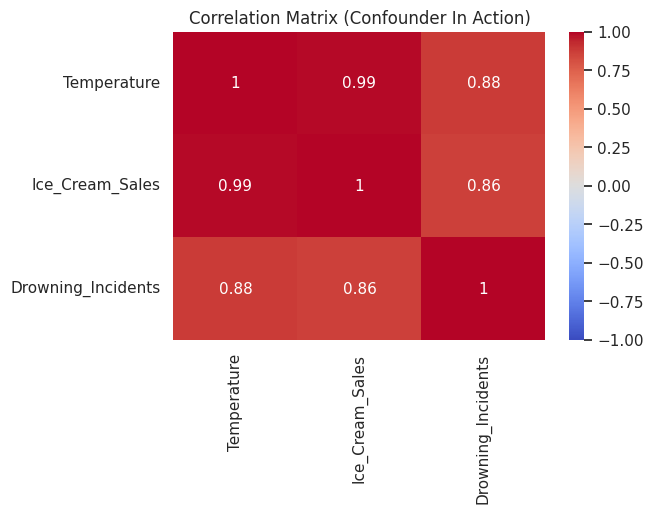

In [ ]:
# ==============================================================================
# SECTION 7: COVARIANCE, CORRELATION & SPURIOUS CORRELATION
# ==============================================================================
# - Covariance: Direction of linear relationship (scale-dependent, unstandardised).
# - Pearson Correlation (r): Standardised linear strength in [-1.0, 1.0].
# - Spearman Correlation (ρ): Rank-based; measures MONOTONIC relationships (handles non-linear curves & outliers).

# SPUROUS CORRELATION DEMONSTRATION:
# Confounder: Daily Summer Temperature drives BOTH Ice Cream Sales and Drowning Incidents.
np.random.seed(42)
temp = np.random.uniform(20, 38, 100) # Temperature in Celsius
ice_cream_sales = temp * 50 + np.random.normal(0, 50, 100)
drowning_incidents = temp * 1.5 + np.random.normal(0, 4, 100)

spurious_df = pd.DataFrame({
    'Temperature': temp,
    'Ice_Cream_Sales': ice_cream_sales,
    'Drowning_Incidents': drowning_incidents
})

r, p_val = stats.pearsonr(spurious_df['Ice_Cream_Sales'], spurious_df['Drowning_Incidents'])
print("=== Spurious Correlation Analysis ===")
print(f"Pearson Correlation between Ice Cream Sales & Drownings: r = {r:.3f} (p < 0.001)")
print("INTERPRETATION: Highly correlated! Does ice cream cause drowning? NO.")
print("The lurking confounding variable is TEMPERATURE (hot weather causes both).")

# Visual Correlation Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(spurious_df.corr(method='pearson'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (Confounder In Action)")
plt.show()

.desc - yayy it will be used cuz it gives statiticl data

In [ ]:
# ==============================================================================
# SECTION 8: LIVE CODE DEMO — MANUAL STATISTICAL SUMMARY VS DF.DESCRIBE()
# ==============================================================================
# We will generate a dataset, build a manual statistical profile with pure NumPy,
# and verify it down to the decimal point against pd.DataFrame.describe().

np.random.seed(101)
raw_test_data = np.random.lognormal(mean=3.0, sigma=0.75, size=250)
test_series = pd.Series(raw_test_data, name="Revenue_USD")

def manual_describe(arr: np.ndarray) -> dict:
    """Computes full parametric and non-parametric summary statistics manually."""
    n = len(arr)
    mean_val = np.sum(arr) / n
    # Sample variance with Bessel's correction (ddof=1)
    variance_val = np.sum((arr - mean_val) ** 2) / (n - 1)
    std_val = np.sqrt(variance_val)

    sorted_arr = np.sort(arr) #sorts in acending order
    min_val = sorted_arr[0]
    max_val = sorted_arr[-1]

    # Percentiles matching Pandas linear interpolation standard
    p25 = np.percentile(sorted_arr, 25)
    p50 = np.percentile(sorted_arr, 50)
    p75 = np.percentile(sorted_arr, 75)

    # Higher order moments
    skew_val = stats.skew(arr)
    kurt_val = stats.kurtosis(arr) # Excess kurtosis

    return {     # if not using .desc -- this is the user defined func that u have to write to des cthe dat by urself
        'count': float(n),
        'mean': mean_val,
        'std': std_val,
        'min': min_val,
        '25%': p25,
        '50%': p50,
        '75%': p75,
        'max': max_val,
        'skewness': skew_val,
        'kurtosis': kurt_val
    }

# 1. Manual Profile
manual_stats = manual_describe(raw_test_data)
manual_df = pd.DataFrame(list(manual_stats.items()), columns=['Metric', 'Manual_NumPy']).set_index('Metric')

# 2. Pandas Native Describe     #easier
pandas_stats = test_series.describe()
pandas_stats.loc['skewness'] = test_series.skew()
pandas_stats.loc['kurtosis'] = test_series.kurt()
manual_df['Pandas_Native'] = pandas_stats

print("=== VERIFICATION: MANUAL NUMPY VS PANDAS DESCRIBE() ===")
display(manual_df.round(4))

# Formal programmatic assertion
for metric in ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']:
    assert np.isclose(manual_df.loc[metric, 'Manual_NumPy'], manual_df.loc[metric, 'Pandas_Native']), f"Mismatch in {metric}"
print("\n All manual calculations match `df.describe()` with precision.")

=== VERIFICATION: MANUAL NUMPY VS PANDAS DESCRIBE() ===


,Manual_NumPy,Pandas_Native
Metric,,
count,250.0000,250.0000
mean,28.2408,28.2408
std,24.7283,24.7283
min,2.5786,2.5786
25%,11.3235,11.3235
50%,22.6078,22.6078
75%,34.6476,34.6476
max,152.9540,152.9540
skewness,2.2102,2.2236



 All manual calculations match `df.describe()` with precision.


VARIABLE: Annual_Income
Mean: 50,446.98
Median: 39,267.91
Std Dev: 35,954.99
IQR: 37,258.04
Skewness: 2.011
Outlier Count: 33
Diagnosis: Right-Skewed

VARIABLE: Test_Score
Mean: 90.10
Median: 92.73
Std Dev: 9.52
IQR: 10.89
Skewness: -1.636
Outlier Count: 22
Diagnosis: Left-Skewed

VARIABLE: Product_Weight
Mean: 4.98
Median: 4.97
Std Dev: 0.54
IQR: 0.72
Skewness: -0.019
Outlier Count: 2
Diagnosis: Symmetric

      Variable         Mean       Median      Std Dev          IQR  Skewness  Outliers    Diagnosis
 Annual_Income 50446.981027 39267.913164 35954.992909 37258.039828  2.011327        33 Right-Skewed
    Test_Score    90.095913    92.726563     9.519524    10.891458 -1.635994        22  Left-Skewed
Product_Weight     4.983883     4.970808     0.539296     0.716836 -0.018943         2    Symmetric


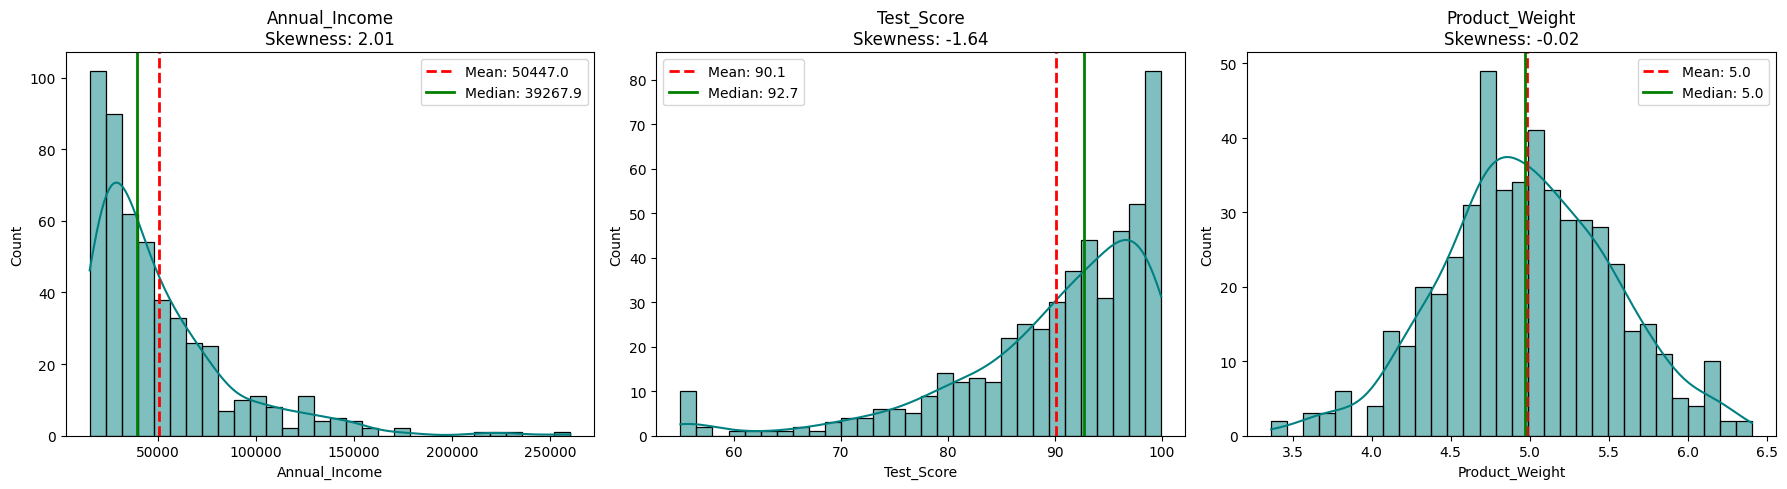

Annual_Income: Median
Test_Score: Median
Product_Weight: Mean


In [2]:
# ==============================================================================
# SECTION 9: STUDENT PRACTICE LAB — STATISTICAL DIAGNOSTICS & SKEW PROFILING
# ==============================================================================
"""
STUDENT LAB INSTRUCTIONS:
You are provided with a DataFrame `market_df` containing 3 variables:
  1. `Annual_Income`: Customer reported earnings in USD.
  2. `Test_Score`: Standardized assessment score out of 100.
  3. `Product_Weight`: Packaging weight in kilograms.

YOUR TASKS:
1. For each variable, compute: Mean, Median, Std Dev, IQR, Skewness, and Count of Outliers (using 1.5x IQR).
2. Diagnose the skewness direction for all three (Left-Skewed, Symmetric, or Right-Skewed).
3. Determine which measure of central tendency (Mean vs Median) should be reported for business decisions.
"""
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
# Generate Student Data
np.random.seed(999)   #for randomization for data . 1st run- gves value 999 gives value ater shuffling for 999 times
market_df = pd.DataFrame({
    'Annual_Income': np.random.exponential(scale=35_000, size=500) + 15_000,
    'Test_Score': 100 - np.random.exponential(scale=10, size=500).clip(0, 45),
    'Product_Weight': np.random.normal(loc=5.0, scale=0.5, size=500)
})

# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)
# ------------------------------------------------------------------------------


variables = ["Annual_Income", "Test_Score", "Product_Weight"]

for col in variables:
    data = market_df[col]

    mean = data.mean()
    median = data.median()
    std_dev = data.std(ddof=1)

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    outlier_count = ((data < lower_fence) | (data > upper_fence)).sum()

    skewness = stats.skew(data)

    if skewness > 0.5:
        diagnosis = "Right-Skewed"
    elif skewness < -0.5:
        diagnosis = "Left-Skewed"
    else:
        diagnosis = "Symmetric"

    print("=" * 60)
    print(f"VARIABLE: {col}")
    print("=" * 60)
    print(f"Mean: {mean:,.2f}")
    print(f"Median: {median:,.2f}")
    print(f"Std Dev: {std_dev:,.2f}")
    print(f"IQR: {iqr:,.2f}")
    print(f"Skewness: {skewness:.3f}")
    print(f"Outlier Count: {outlier_count}")
    print(f"Diagnosis: {diagnosis}")
    print()


summary = []

for col in variables:
    data = market_df[col]

    mean = data.mean()
    median = data.median()
    std_dev = data.std(ddof=1)

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    outlier_count = ((data < lower_fence) | (data > upper_fence)).sum()
    skewness = stats.skew(data)

    if skewness > 0.5:
        diagnosis = "Right-Skewed"
    elif skewness < -0.5:
        diagnosis = "Left-Skewed"
    else:
        diagnosis = "Symmetric"

    summary.append({
        "Variable": col,
        "Mean": mean,
        "Median": median,
        "Std Dev": std_dev,
        "IQR": iqr,
        "Skewness": skewness,
        "Outliers": outlier_count,
        "Diagnosis": diagnosis
    })

summary_df = pd.DataFrame(summary)

print(summary_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, variables):
    data = market_df[col]

    sns.histplot(data, kde=True, ax=ax, color="teal", bins=30)

    ax.axvline(
        data.mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {data.mean():.1f}"
    )

    ax.axvline(
        data.median(),
        color="green",
        linestyle="-",
        linewidth=2,
        label=f"Median: {data.median():.1f}"
    )

    skew_value = stats.skew(data)

    ax.set_title(f"{col}\nSkewness: {skew_value:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

for col in variables:
    skew_value = stats.skew(market_df[col])

    if abs(skew_value) > 0.5:
        recommendation = "Median"
    else:
        recommendation = "Mean"

    print(f"{col}: {recommendation}")


